# Survival Analysis on the MIMIC Dataset

We consider a longitudinal clinical dataset extracted from the MIMIC database.  
Each patient is associated with several chronological medical reports collected during the follow-up period.

The dataframe contains the following variables:

- `'SUBJECT_ID'`: Unique identifier of a patient. A single patient may have several associated observations (clinical reports).
- `'note_time'`: Datetime $t_j$ corresponding to the $j$-th clinical report of a patient.
- `'embeddings'`:  Sentence embedding extracted from the clinical report. These embeddings are obtained using a biomedical NLP model followed by a SIF aggregation procedure applied to contextual word embeddings. Each embedding is represented as a vector in
  $\mathbb{R}^p$, where typically $p = 768$.
- `'delta_i'`: Event indicator associated with patient $i$. It's formally written as:
  $$
  \delta_i =
  \begin{cases}
  1 & \text{if the event is observed (death)}, \\
  0 & \text{if the patient is censored.}
  \end{cases}
  $$

- `'survival_time'` (or $T_i$): Observed survival time of patient $i$, expressed in days.
- `'time_since_first_note'`: Relative time elapsed since the first available report of the patient.
- `'death_time'`: Datetime of death if the event occurred. This variable is equal to `NaN` for censored patients.

The objective is to transform the sequential trajectory of embeddings into meaningful covariates for survival analysis using the SigBERT pipeline:
1. temporal normalization,
2. path construction,
3. signature feature extraction,
4. Cox proportional hazards modeling.

In [1]:
import types
import sys
from numbers import Real, Integral

# Create a fake module to emulate 'sklearn.utils._param_validation'
# (used by skglm in newer versions of scikit-learn, >=1.3)
param_validation = types.ModuleType("sklearn.utils._param_validation")

# Define a minimal replacement for Interval used in _parameter_constraints
class Interval:
    def __init__(self, dtype, left, right, closed="neither"):
        self.dtype = dtype
        self.left = left
        self.right = right
        self.closed = closed

# Define a minimal replacement for StrOptions used in _parameter_constraints
class StrOptions:
    def __init__(self, options):
        self.options = set(options)

# Add the custom classes to the fake module
param_validation.Interval = Interval
param_validation.StrOptions = StrOptions

# Inject the fake module into sys.modules before skglm is imported
# This prevents skglm from raising an ImportError if sklearn < 1.3
sys.modules["sklearn.utils._param_validation"] = param_validation

In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd
import skglm
from tqdm import tqdm

In [3]:
print("Jupyter is running on:", sys.executable)

Jupyter is running on: /Applications/anaconda3/envs/sigbert-env/bin/python


In [4]:
# Add the src directory to the Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import our custom modules
from utils import *
from compression_pkg import *
from survival_analysis_sigbert import *

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

## I) Data Importation

In [6]:
df_OG = pd.read_parquet("../data/all_report_embeddings.parquet",engine="pyarrow")
# df_OG = pd.read_parquet("../data/all_report_embeddings.parquet",engine="pyarrow").head(1000).copy()

In [7]:
print("Total shape:", df_OG.shape)

Total shape: (456330, 11)


In [8]:
df_OG = convert_date_columns(df_OG)

In [9]:
df_OG = convert_embedding_strings(df_OG,var_embd="embeddings")

In [10]:
print_dataset_statistics(df_OG, var_id="SUBJECT_ID", var_death="delta_i")

Total number of patients in the dataset: 9644
Total number of medical reports: 456330
Average number of reports per patient: 47.32
Number of deceased patients: 3635
Number of censored patients: 6009


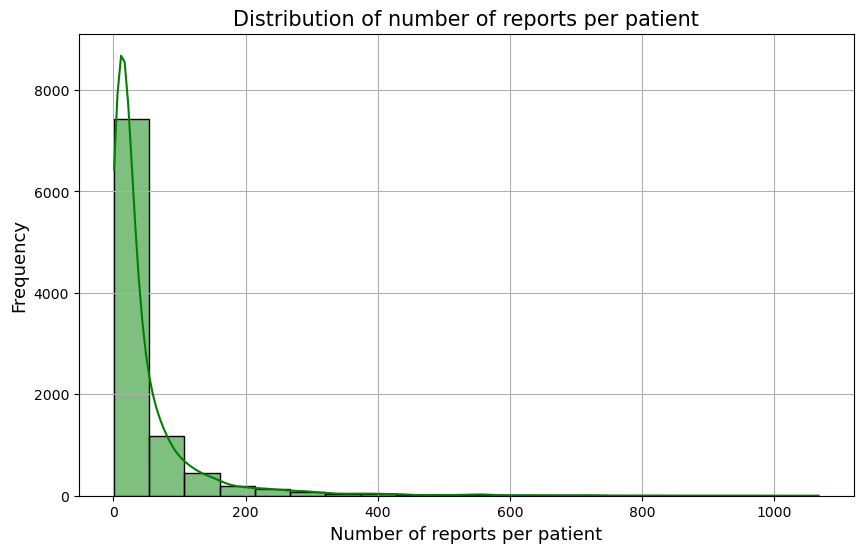

In [11]:
plot_report_distribution_per_patient(df_OG, var_id="SUBJECT_ID", export_path=None)

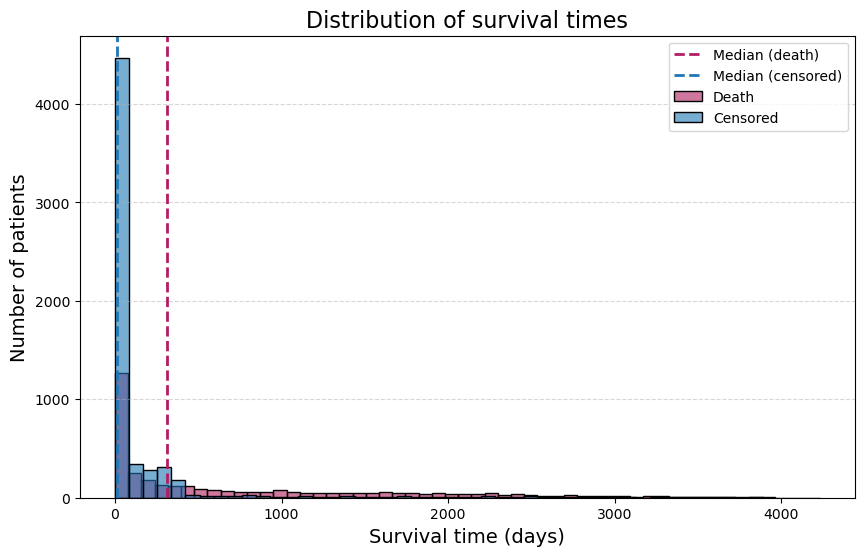

Number of unique patients: 9644
Number of deceased patients: 3635
Number of censored patients: 6009

Deceased patients
-----------------
count    3635.000000
mean      757.278680
std       925.491957
min         0.000000
25%        33.000000
50%       312.000000
75%      1301.500000
max      3963.000000
Name: survival_time, dtype: float64

Censored patients
-----------------
count    6009.000000
mean      178.126643
std       517.436110
min         0.000000
25%         2.000000
50%        12.000000
75%        91.000000
max      4230.000000
Name: survival_time, dtype: float64


In [12]:
df_patient, stats_deceased, stats_censored = plot_survival_time_distribution(df_OG)

## II) Survival Modeling

### II)1) Landmark modeling

In [13]:
df_OG.head(1)

,SUBJECT_ID,note_time,TEXT,event,death_time,time_since_first_note,survival_time,report_word_count,Ti,delta_i,embeddings
0,20,2183-04-16,[**2183-4-16**] 11:38 AM\n CHEST (PRE-OP PA & ...,0,None,0,23.0,81,23.0,0,"[-0.0018343869596719742, -0.021196581423282623..."


```python
L_chosen = 10; w_chosen = 10  # Adapt the landmark point and window size by yourself.

# Build the landmark cohort
df_L, patients_L, df_gamma_L = define_landmark_cohort(
    df_OG,
    landmark_months=L_chosen,
    var_time = 'note_time',
    var_id = 'SUBJECT_ID',
    var_since_start = 'time_since_first_note',
    var_T = 'Ti',
    window_months=w_chosen
)
```

In [14]:
L_chosen = 36; w_chosen = 24  # Adapt the landmark point and window size by yourself.

# Build the landmark cohort
df_L, patients_L, df_gamma_L = define_landmark_cohort(
    df_OG,
    landmark_months=L_chosen,
    var_time = 'note_time',
    var_id = 'SUBJECT_ID',
    var_since_start = 'time_since_first_note',
    var_T = 'Ti',
    window_months=w_chosen
)

[Landmark 36 mo] Patients kept: 1348/9644 (8296 excluded)
  → Short-history γ=1: 512/1348 = 38.0%
  → Observations kept: 13430/95472 (14.1% retained, 85.9% removed)
  → Residual survival R_i computed (min=6.0 days).
  → Landmark events computed: DEATH_L sum = 9073.


In [15]:
df_L = df_OG.copy()

In [16]:
# Count number of clinical reports in the window
df_counts = (
    df_L.groupby("SUBJECT_ID")
        .size()
        .reset_index(name="n_reports")
)
mean_reports = df_counts["n_reports"].mean()
std_reports = df_counts["n_reports"].std(ddof=1)

In [17]:
# Train-test construction
df_train_new_OG, test_groups = make_train_test(df_L, n_group=10, size_test=0.5, min_date=None, random_state=18)

Initial rows: 456330
Initial patients: 9644
Training patients: 4822
Test group 1: 483 patients
Test group 2: 483 patients
Test group 3: 482 patients
Test group 4: 482 patients
Test group 5: 482 patients
Test group 6: 482 patients
Test group 7: 482 patients
Test group 8: 482 patients
Test group 9: 482 patients
Test group 10: 482 patients


In [18]:
k_comp = 25

# PCA compression
V_proj, R_comp, mean_embedding, explained_ratio = pca_compression(df_train_new_OG, k_comp, verbose=True)

df_all = df_L.copy()

Original dimension: 768
Compressed dimension: 25
Explained variance ratio: 93.92%


In [19]:
np.allclose(df_all["survival_time"], df_all["Ti"], equal_nan=True)

True

In [20]:
# lambda_list_RO = np.arange(0.01, 0.2, 0.05)

```python
lambda_list_RO = [0.07, 0.1, 0.2, 0.5]

results_summary_RO = []
global_lambda_results_RO = {}

start_global_RO = time.time()

for lambda_l1_CV_RO in tqdm(lambda_list_RO):

    print("\n===================================")
    print(f"Running Reports Only for lambda = {lambda_l1_CV_RO}")
    print("===================================")

    start = time.time()

    (
        df_pipeline_results_RO,
        cph_RO,
        df_survival_RO,
        w_sk_RO,
        scores_RO,
        X_RO,
        y_train_RO,
        y_cox_RO,
        c_index_train_RO,
        c_index_test_list_RO,
        c_index_test_mean_RO,
        c_index_test_std_RO,
        df_survival_test_list_RO,
        df_test_metrics_RO
    ) = global_sigbert_mimic_pipeline(
        df_full=df_all,
        df_train=df_train_new_OG,
        test_groups=test_groups,
        projection_matrix=R_comp,
        mean_embedding=mean_embedding,
        lambda_l1=lambda_l1_CV_RO,
        signature_order=2,
        use_levy_area=False,
        print_progress=False,
        patient_id_col="SUBJECT_ID",
        embedding_col="embeddings",
        timestamp_col="note_time",
        event_col="delta_i",
        duration_col="survival_time",
        use_standard_scaling=False
    )
    
    # Number of selected Cox coefficients
    non_zero_coefficients_RO = int((w_sk_RO != 0).sum())
    
    # Confidence interval across test groups
    lower_bound_RO, upper_bound_RO = jackknife_confidence_interval(
        c_index_test_list_RO
    )
    
    # Detailed results for each test group
    display(df_test_metrics_RO)

    non_zero_coefficients_RO = int((w_sk_RO != 0).sum())

    lower_bound_RO, upper_bound_RO = jackknife_confidence_interval(
        c_index_test_list_RO
    )

    execution_time_minutes = (time.time() - start) / 60

    global_lambda_results_RO[lambda_l1_CV_RO] = {
        "pipeline_results": df_pipeline_results_RO.copy(),
        "model": cph_RO,
        "survival_train": df_survival_RO.copy(),
        "cox_coefficients": w_sk_RO.copy(),
        "scores": scores_RO,
        "X_train": X_RO,
        "y_train": y_train_RO,
        "y_cox": y_cox_RO,
        "c_index_train": c_index_train_RO,
        "c_index_test_list": list(c_index_test_list_RO),
        "c_index_test_mean": c_index_test_mean_RO,
        "c_index_test_std": c_index_test_std_RO,
        "survival_test_list": [
            df_test.copy()
            for df_test in df_survival_test_list_RO
        ],
        "non_zero_coefficients": non_zero_coefficients_RO,
        "execution_time_minutes": execution_time_minutes
    }

    results_summary_RO.append({
        "lambda": lambda_l1_CV_RO,
        "C-index Train": np.round(c_index_train_RO, 3),
        "Mean C-index Test": np.round(c_index_test_mean_RO, 3),
        "C-index Test Std": np.round(c_index_test_std_RO, 3),
        "C-index CI95%": (
            f"[{lower_bound_RO:.4f}, {upper_bound_RO:.4f}]"
        ),
        "Non-zero Coefficients": non_zero_coefficients_RO,
        "Execution Time (min)": np.round(
            execution_time_minutes,
            2
        )
    })
```

```python
df_results_RO = pd.DataFrame(results_summary_RO)

total_execution_time_RO = (time.time() - start_global_RO) / 60

print("\n===================================")
print("Global Reports Only results")
print("===================================")
print(df_results_RO)
print(
    f"\nTotal execution time: "
    f"{total_execution_time_RO:.2f} minutes"
)
```

```python
df_results_RO
```

```python
# Select best lambda
best_row_RO = df_results_RO.loc[df_results_RO["Mean C-index Test"].idxmax()]
best_lambda_RO = best_row_RO["lambda"]


print(
    f"Best lambda (Reports Only): "
    f"{best_lambda_RO:.3f}"
)
print("----------------------------------------")

print(best_row_RO)
```

## LASSO refit

In [21]:
lambda_l1_CV_RO = 0.1

global_lambda_results_RO = {}
results_summary_RO = []

print("\n===================================")
print(f"Running Reports Only for lambda = {lambda_l1_CV_RO}")
print("===================================")

start_pipeline = time.time()

(
    df_pipeline_results_RO,
    cph_RO,
    df_survival_RO,
    w_sk_RO,
    scores_RO,
    X_RO,
    y_train_RO,
    y_cox_RO,
    c_index_train_RO,
    c_index_test_list_RO,
    c_index_test_mean_RO,
    c_index_test_std_RO,
    df_survival_test_list_RO,
    df_test_metrics_RO,
    X_test_list_RO,
    y_test_list_RO
) = global_sigbert_mimic_pipeline(
    df_full=df_all,
    df_train=df_train_new_OG,
    test_groups=test_groups,
    projection_matrix=R_comp,
    mean_embedding=mean_embedding,
    lambda_l1=lambda_l1_CV_RO,
    signature_order=2,
    use_levy_area=False,
    print_progress=False,
    patient_id_col="SUBJECT_ID",
    embedding_col="embeddings",
    timestamp_col="note_time",
    event_col="delta_i",
    duration_col="survival_time",
    use_standard_scaling=False
)

lasso_execution_time_minutes = (time.time() - start_pipeline) / 60

# Number of covariates selected by the LASSO
non_zero_coefficients_RO = int(
    (np.abs(np.asarray(w_sk_RO)) > 1e-12).sum()
)

# Confidence interval across test groups
lower_bound_RO, upper_bound_RO = jackknife_confidence_interval(
    c_index_test_list_RO
)


Running Reports Only for lambda = 0.1

### Running SigBERT pipeline on MIMIC dataset ###
Number of test groups received: 10
Total number of patients in train set: 4209
Test group 1: 422 patients, 27355 reports
Test group 2: 425 patients, 23109 reports
Test group 3: 425 patients, 24694 reports
Test group 4: 411 patients, 23029 reports
Test group 5: 420 patients, 24385 reports
Test group 6: 442 patients, 24009 reports
Test group 7: 428 patients, 21439 reports
Test group 8: 424 patients, 20953 reports
Test group 9: 421 patients, 21217 reports
Test group 10: 414 patients, 21858 reports
Total number of patients across all test groups: 4232
Timestamps normalized for each patient to the [0, 1] range.
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 1775 out of 4209 (42.17%)

--------------- Cox training ---------------
 --------> X.shape: (4209, 702)

 --------> y.shape: (4209, 2)



/Applications/anaconda3/envs/sigbert-env/lib/python3.8/site-packages/skglm/solvers/prox_newton.py:433: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'C', False, aligned=True))
  grad[idx] = X[:, j] @ raw_grad


Number of nonzero coefficients in solution: 190 out of 702.
w_sk.shape: (702,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.762
Execution time: 1650.21 seconds (27.50 minutes)

        Scores:
        C-index        = 0.762
        Log-likelihood = -2.81
        
--------------------------------------------

Evaluation on test group 1/10
Patients before signature: 422
Reports: 27355
Timestamps normalized for each patient to the [0, 1] range.
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 173 out of 422 (41.00%)
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 0.695

Evaluation on test group 2/10
Patients before signature: 425
Reports: 23109
Timestamps normalized for each patient to the [0, 1] range.
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 175 out of 425 (41.18%)
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 0.740


NameError: name 'evaluate_brier_score_multiple_tests' is not defined

In [22]:
from metrics_plot_results_pkg import *

In [24]:
# =====================================================
# Brier Score @ 1, 2 and 3 years
# =====================================================

target_times = {
    "1 year": 365,
    "2 years": 730,
    "3 years": 1095
}

brier_summary_rows = []

for label, time_value in target_times.items():
    idx_time = np.where(evaluation_times == time_value)[0][0]
    brier_per_test = brier_scores_array_RO[:, idx_time]
    brier_mean = np.mean(brier_per_test)
    brier_std = np.std(brier_per_test, ddof=1)
    lower_ci, upper_ci = jackknife_confidence_interval(brier_per_test)

    brier_summary_rows.append({
        "Time horizon": label,
        "Time (days)": time_value,
        "Brier Score Mean": brier_mean,
        "Brier Score Std": brier_std,
        "95% CI Lower": lower_ci,
        "95% CI Upper": upper_ci
    })


df_brier_summary_RO = pd.DataFrame(brier_summary_rows)

print("\nLASSO test results by group:")
display(df_test_metrics_RO)

print("\nBrier Score summary:")
display(
    df_brier_summary_RO.style.format({
        "Brier Score Mean": "{:.4f}",
        "Brier Score Std": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)


LASSO test results by group:


,Test group,Number of reports,Patients before signature,Patients evaluated,Events,Censored,C-index
0,1,27355,422,422,173,249,0.694863
1,2,23109,425,425,175,250,0.739584
2,3,24694,425,425,194,231,0.695423
3,4,23029,411,411,163,248,0.717775
4,5,24385,420,420,188,232,0.703549
5,6,24009,442,442,186,256,0.714397
6,7,21439,428,428,198,230,0.725318
7,8,20953,424,424,172,252,0.763957
8,9,21217,421,421,182,239,0.721091
9,10,21858,414,414,163,251,0.749230



Brier Score summary:


,Time horizon,Time (days),Brier Score Mean,Brier Score Std,95% CI Lower,95% CI Upper
0,1 year,365,0.0800,0.0199,0.0677,0.0924
1,2 years,730,0.1397,0.0244,0.1245,0.1548
2,3 years,1095,0.1927,0.0266,0.1763,0.2092


```python
# Recover patient IDs when available
patient_ids_RO = None

if (
    isinstance(df_survival_RO, pd.DataFrame)
    and "SUBJECT_ID" in df_survival_RO.columns
):
    patient_ids_RO = df_survival_RO["SUBJECT_ID"].to_numpy()

# Post-LASSO refit
start_post_lasso = time.time()
# Recover training observations only
df_survival_train_RO = (
    df_survival_RO.loc[
        df_survival_RO["dataset_split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

n_train_RO = len(y_train_RO)

X_train_refit_RO = np.asarray(
    X_RO[:n_train_RO],
    dtype=np.float64
)

patient_ids_train_RO = (
    df_survival_train_RO["ID"]
    .to_numpy()
)

if X_train_refit_RO.shape[0] != len(y_train_RO):
    raise ValueError(
        "X_train and y_train do not contain the same number "
        "of observations."
    )

if len(patient_ids_train_RO) != len(y_train_RO):
    raise ValueError(
        "The number of training patient IDs does not match y_train."
    )

post_lasso_results_RO = post_lasso_cox_refit(
    X_train=X_train_refit_RO,
    y_train=y_train_RO,
    lasso_coefficients=w_sk_RO,
    df_survival=df_survival_train_RO,
    patient_ids=patient_ids_train_RO,
    patient_id_col="SUBJECT_ID",
    learning_cox_map="sk_cox",
    coefficient_tolerance=1e-12,
    refit_lambda=0.0,
    verbose=True
)

post_lasso_execution_time_minutes = (
    time.time() - start_post_lasso
) / 60
```

```python
cph_post_lasso_RO = post_lasso_results_RO["model"]
w_post_lasso_RO = post_lasso_results_RO["full_coefficients"]
w_post_lasso_selected_RO = post_lasso_results_RO["selected_coefficients"]
selected_mask_RO = post_lasso_results_RO["selected_mask"]
selected_indices_RO = post_lasso_results_RO["selected_indices"]
selected_feature_names_RO = post_lasso_results_RO["selected_feature_names"]
X_post_lasso_RO = post_lasso_results_RO["X_selected"]
c_index_train_post_lasso_RO = post_lasso_results_RO["c_index_train"]
log_likelihood_post_lasso_RO = post_lasso_results_RO["log_likelihood"]

total_execution_time_minutes = (
    lasso_execution_time_minutes
    + post_lasso_execution_time_minutes
)

# Store all outputs for the selected lambda
global_lambda_results_RO[lambda_l1_CV_RO] = {
    "pipeline_results": df_pipeline_results_RO.copy(),
    "lasso": {
        "model": cph_RO,
        "cox_coefficients": np.asarray(w_sk_RO).copy(),
        "scores": scores_RO,
        "X_train": X_RO,
        "y_train": y_train_RO,
        "y_cox": y_cox_RO,
        "survival_train": df_survival_RO.copy(),
        "survival_test_list": [
            df_test.copy()
            for df_test in df_survival_test_list_RO
        ],
        "test_metrics": df_test_metrics_RO.copy(),
        "c_index_train": c_index_train_RO,
        "c_index_test_list": list(c_index_test_list_RO),
        "c_index_test_mean": c_index_test_mean_RO,
        "c_index_test_std": c_index_test_std_RO,
        "non_zero_coefficients": non_zero_coefficients_RO,
        "execution_time_minutes": lasso_execution_time_minutes
    },
    "post_lasso": {
        "model": cph_post_lasso_RO,
        "selected_mask": selected_mask_RO.copy(),
        "selected_indices": selected_indices_RO.copy(),
        "selected_feature_names": selected_feature_names_RO.copy(),
        "X_selected": X_post_lasso_RO.copy(),
        "selected_coefficients": w_post_lasso_selected_RO.copy(),
        "full_coefficients": w_post_lasso_RO.copy(),
        "c_index_train": c_index_train_post_lasso_RO,
        "log_likelihood": log_likelihood_post_lasso_RO,
        "execution_time_minutes": post_lasso_execution_time_minutes
    }
}

results_summary_RO.append({
    "lambda": lambda_l1_CV_RO,
    "LASSO C-index Train": np.round(c_index_train_RO, 3),
    "Post-LASSO C-index Train": np.round(
        c_index_train_post_lasso_RO,
        3
    ),
    "Mean C-index Test": np.round(
        c_index_test_mean_RO,
        3
    ),
    "C-index Test Std": np.round(
        c_index_test_std_RO,
        3
    ),
    "C-index CI95%": (
        f"[{lower_bound_RO:.4f}, {upper_bound_RO:.4f}]"
    ),
    "Selected Covariates": non_zero_coefficients_RO,
    "LASSO Time (min)": np.round(
        lasso_execution_time_minutes,
        2
    ),
    "Post-LASSO Time (min)": np.round(
        post_lasso_execution_time_minutes,
        2
    ),
    "Total Time (min)": np.round(
        total_execution_time_minutes,
        2
    )
})
```

```python
(
    df_post_lasso_test_metrics_RO,
    c_index_test_post_lasso_list_RO
) = evaluate_post_lasso_on_test_groups(
    post_lasso_coefficients=(w_post_lasso_selected_RO),
    X_test_list=X_test_list_RO,
    y_test_list=y_test_list_RO,
    selected_mask=selected_mask_RO,
    lasso_c_index_list=c_index_test_list_RO,
    group_names=[f"Test group {i + 1}"for i in range(len(X_test_list_RO))],
    plot=True
)

c_index_test_post_lasso_mean_RO = float(
    np.mean(c_index_test_post_lasso_list_RO)
)

c_index_test_post_lasso_std_RO = float(
    np.std(
        c_index_test_post_lasso_list_RO,
        ddof=1
    )
) if len(c_index_test_post_lasso_list_RO) > 1 else 0.0

(
    lower_bound_post_lasso_RO,
    upper_bound_post_lasso_RO
) = jackknife_confidence_interval(
    c_index_test_post_lasso_list_RO
)

display(df_post_lasso_test_metrics_RO)

print(
    "\nPost-LASSO mean test C-index: "
    f"{c_index_test_post_lasso_mean_RO:.4f}"
)

print(
    "Post-LASSO test C-index standard deviation: "
    f"{c_index_test_post_lasso_std_RO:.4f}"
)

print(
    "Post-LASSO test C-index 95% CI: "
    f"[{lower_bound_post_lasso_RO:.4f}, "
    f"{upper_bound_post_lasso_RO:.4f}]"
)
```

```python
global_lambda_results_RO[lambda_l1_CV_RO]["post_lasso"].update({
    "test_metrics": df_post_lasso_test_metrics_RO.copy(),
    "c_index_test_list": list(
        c_index_test_post_lasso_list_RO
    ),
    "c_index_test_mean": c_index_test_post_lasso_mean_RO,
    "c_index_test_std": c_index_test_post_lasso_std_RO,
    "c_index_test_ci95": (
        lower_bound_post_lasso_RO,
        upper_bound_post_lasso_RO
    )
})

results_summary_RO[-1].update({
    "Post-LASSO Mean C-index Test": np.round(
        c_index_test_post_lasso_mean_RO,
        3
    ),
    "Post-LASSO C-index Test Std": np.round(
        c_index_test_post_lasso_std_RO,
        3
    ),
    "Post-LASSO C-index CI95%": (
        f"[{lower_bound_post_lasso_RO:.4f}, "
        f"{upper_bound_post_lasso_RO:.4f}]"
    )
})
```

In [ ]:
df_results_RO = pd.DataFrame(results_summary_RO)
display(df_results_RO)

In [ ]:
# df_all.drop(columns=["TEXT"]).to_parquet("../data/df_mimic_L36_w24.parquet",engine="pyarrow",compression="snappy",index=False)